In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [123]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [124]:
df=pd.read_csv('/content/drive/MyDrive/train.csv')
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [125]:
df.shape

(42000, 785)

In [126]:
df.label.unique()

array([1, 0, 4, 7, 3, 5, 8, 9, 2, 6])

In [127]:
df.iloc[13051]

,13051
label,0
pixel0,0
pixel1,0
pixel2,0
pixel3,0
...,...
pixel779,0
pixel780,0
pixel781,0
pixel782,0


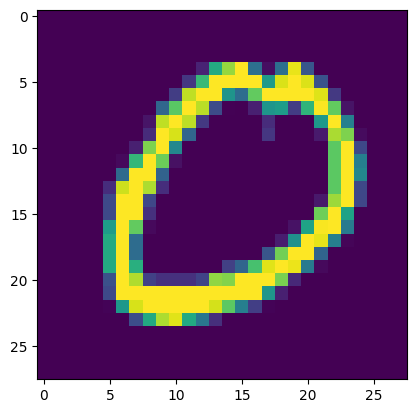

In [128]:
plt.imshow(df.iloc[13051,1:].values.reshape(28,28))
plt.show()

In [129]:
x=df.iloc[:,1:]
y=df.iloc[:,0]

In [130]:
x

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [131]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [132]:
x_train.shape

(33600, 784)

In [133]:
from sklearn.decomposition import PCA

In [134]:
pca=PCA()

In [135]:
df.isnull()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
41996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
41997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
41998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [136]:
x_train_trf=pca.fit_transform(x_train)
x_test_trf=pca.transform(x_test)

In [137]:
from sklearn.neighbors import KNeighborsClassifier

In [138]:
knn=KNeighborsClassifier()


In [139]:
knn.fit(x_train_trf,y_train)

KNeighborsClassifier()

In [140]:
y_pred=knn.predict(x_test_trf)

In [141]:
from sklearn.metrics import accuracy_score

In [142]:
accuracy_score(y_test,y_pred)

0.9648809523809524

In [143]:
pca=PCA(n_components=100)

x_train_trf=pca.fit_transform(x_train)
x_test_trf=pca.transform(x_test)

In [144]:
x_train_trf.shape

(33600, 100)

In [145]:
knn.fit(x_train_trf,y_train)

KNeighborsClassifier()

In [146]:
y_pred=knn.predict(x_test_trf)

In [147]:
accuracy_score(y_test,y_pred)

0.9692857142857143

In [148]:
accuracies=[]
for i in range(1,785):
  pca=PCA(n_components=i)
  x_train_trf=pca.fit_transform(x_train)
  x_test_trf=pca.transform(x_test)

  knn=KNeighborsClassifier()
  knn.fit(x_train_trf,y_train)

  y_pred=knn.predict(x_test_trf)

  acc=accuracy_score(y_test,y_pred)
  accuracies.append(acc)

  print(i,acc)




1 0.2730952380952381
2 0.42214285714285715
3 0.48488095238095236
4 0.6194047619047619
5 0.7297619047619047
6 0.8188095238095238
7 0.866904761904762
8 0.8938095238095238
9 0.9075
10 0.9247619047619048
11 0.9315476190476191
12 0.9421428571428572
13 0.9492857142857143
14 0.954047619047619
15 0.9544047619047619
16 0.9583333333333334
17 0.9616666666666667
18 0.9626190476190476
19 0.9644047619047619
20 0.9654761904761905
21 0.9665476190476191
22 0.9683333333333334
23 0.9694047619047619
24 0.9703571428571428
25 0.9704761904761905
26 0.9709523809523809
27 0.9708333333333333
28 0.9705952380952381
29 0.9714285714285714
30 0.9716666666666667
31 0.9725
32 0.9720238095238095
33 0.9705952380952381
34 0.9716666666666667
35 0.9710714285714286
36 0.9721428571428572
37 0.9726190476190476
38 0.9720238095238095
39 0.9729761904761904
40 0.9725
41 0.9721428571428572
42 0.9721428571428572
43 0.9726190476190476
44 0.9721428571428572
45 0.9717857142857143
46 0.9717857142857143
47 0.9727380952380953
48 0.973214

KeyboardInterrupt: 

In [149]:
pca=PCA(n_components=2)
x_train_trf=pca.fit_transform(x_train)
x_test_trf=pca.transform(x_test)

In [150]:
x_train_trf

array([[-226.60523462, -305.89437099],
       [  38.33583717,  461.09152047],
       [-305.49225463,  351.67141678],
       ...,
       [ -28.00133402, -596.06287179],
       [ 233.97011308,  -18.64779077],
       [1096.50373629,  254.72333173]])

In [151]:
import plotly.express as px

In [155]:
y_train_trf=y_train.astype(str)
fig=px.scatter(
    x=x_train_trf[:,0],
    y=x_train_trf[:,1],

    color=y_train_trf,
    color_discrete_sequence=px.colors.qualitative.G10
)
fig.show()

In [153]:
pca=PCA(n_components=3)
x_train_trf=pca.fit_transform(x_train)
x_test_trf=pca.transform(x_test)

In [157]:
y_train_trf=y_train.astype(str)
fig=px.scatter_3d(
    x=x_train_trf[:,0],
    y=x_train_trf[:,1],
    z=x_train_trf[:,2],

    color=y_train_trf,
    color_discrete_sequence=px.colors.qualitative.G10
)
fig.show()